In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from google.colab import files
import zipfile
import io

In [ ]:
# Upload the ZIP file from Kaggle
print("Upload your ZIP file (e.g., archive (1).zip):")
uploaded = files.upload()

Upload your ZIP file (e.g., archive (1).zip):


Saving archive.zip to archive (3).zip


In [ ]:
# Extract CSV inside the uploaded ZIP
for file_name in uploaded.keys():
    if file_name.endswith('.zip'):
        with zipfile.ZipFile(io.BytesIO(uploaded[file_name]), 'r') as zip_ref:
            zip_ref.extractall()
            print("Extracted files:", zip_ref.namelist())

Extracted files: ['maharashtra-districts.csv']


In [ ]:
# Load CSV (replace with the correct extracted CSV name)
df = pd.read_csv("census2011.csv")
print("Dataset preview:")
print(df.head())

Dataset preview:
   Ranking                    District        State  Population   Growth  \
0        1                       Thane  Maharashtra  11,060,148  36.01 %   
1        2  North Twenty Four Parganas  West Bengal  10,009,781  12.04 %   
2        3                   Bangalore    Karnataka   9,621,551  47.18 %   
3        4                        Pune  Maharashtra   9,429,408  30.37 %   
4        5             Mumbai Suburban  Maharashtra   9,356,962   8.29 %   

   Sex-Ratio  Literacy  
0        886     84.53  
1        955     84.06  
2        916     87.67  
3        915     86.15  
4        860     89.91  


In [ ]:
X = df_maharashtra[['Population', 'Literacy']]
print("Features preview:")
print(X.head())

Features preview:
    Population  Literacy
0   11060148.0     84.53
3    9429408.0     86.15
4    9356962.0     89.91
10   6107187.0     82.31
27   4653570.0     88.39


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
df_maharashtra['Cluster'] = kmeans.fit_predict(X_scaled)

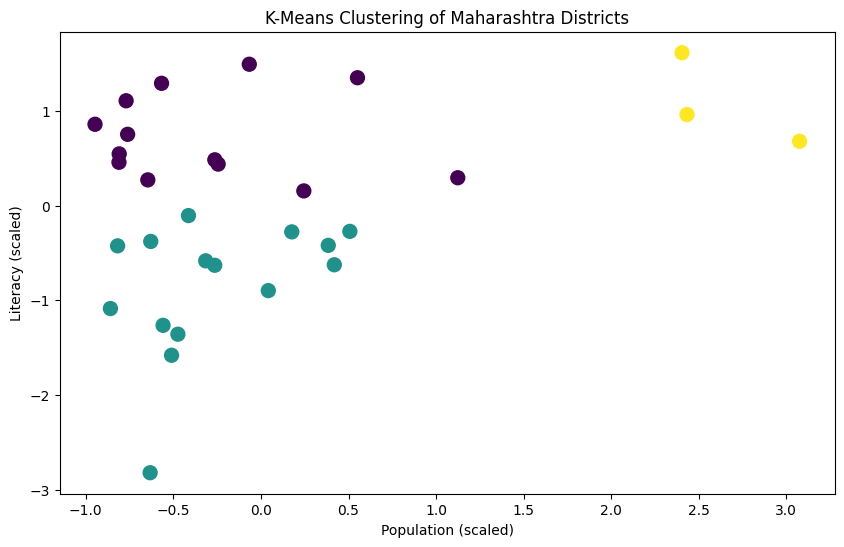

In [ ]:
plt.figure(figsize=(10,6))
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=df_maharashtra['Cluster'], cmap='viridis', s=100)
plt.xlabel("Population (scaled)")
plt.ylabel("Literacy (scaled)")
plt.title("K-Means Clustering of Maharashtra Districts")
plt.show()

In [ ]:
print(df_maharashtra[['District', 'Population', 'Literacy', 'Cluster']])

            District  Population  Literacy  Cluster
0              Thane  11060148.0     84.53        2
3               Pune   9429408.0     86.15        2
4    Mumbai Suburban   9356962.0     89.91        2
10            Nashik   6107187.0     82.31        0
27            Nagpur   4653570.0     88.39        0
32        Ahmadnagar   4543159.0     79.05        1
42           Solapur   4317756.0     77.02        1
45           Jalgaon   4229917.0     78.20        1
64          Kolhapur   3876001.0     81.51        0
70        Aurangabad   3701282.0     79.02        1
98            Nanded   3361292.0     75.45        1
114      Mumbai City   3085411.0     89.21        0
123          Raigarh   2634200.0     83.14        0
128          Buldana   2586258.0     83.40        0
129              Bid   2585049.0     76.99        1
149            Latur   2454196.0     77.26        1
176       Chandrapur   2204307.0     80.01        1
192            Dhule   2050862.0     72.80        1
206         